In [1]:
from google.colab import drive
drive.mount('/content/drive')

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
PROJECT_DIR = Path(
    "/content/drive/MyDrive/PCD_Assignment02"
)

OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

IMAGE_NAME = "city.jpg"

IMAGE_PATH = PROJECT_DIR / IMAGE_NAME

In [3]:
def read_image(path):

    image = cv2.imread(
        str(path),
        cv2.IMREAD_COLOR
    )

    if image is None:
        raise FileNotFoundError(
            f"Image tidak ditemukan: {path}"
        )

    return image


def show_image(
    image,
    title=""
):

    plt.figure(
        figsize=(7, 5)
    )

    image_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    plt.imshow(image_rgb)
    plt.title(title)
    plt.axis("off")
    plt.show()


def show_images(
    images,
    titles,
    cols=3
):

    rows = int(
        np.ceil(
            len(images) / cols
        )
    )

    plt.figure(
        figsize=(15, 5 * rows)
    )

    for i, (
        image,
        title
    ) in enumerate(
        zip(images, titles),
        start=1
    ):

        plt.subplot(
            rows,
            cols,
            i
        )

        image_rgb = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        plt.imshow(image_rgb)
        plt.title(title)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


def save_image(
    filename,
    image
):

    path = OUTPUT_DIR / filename

    cv2.imwrite(
        str(path),
        image
    )

    print(
        f"Saved: {path}"
    )


def mse(
    original,
    result
):

    original = original.astype(
        np.float32
    )

    result = result.astype(
        np.float32
    )

    return np.mean(
        (original - result) ** 2
    )


def psnr(
    original,
    result
):

    error = mse(
        original,
        result
    )

    if error == 0:
        return float("inf")

    return 10 * np.log10(
        (255 ** 2) / error
    )

Image shape: (408, 612, 3)
Image dtype: uint8


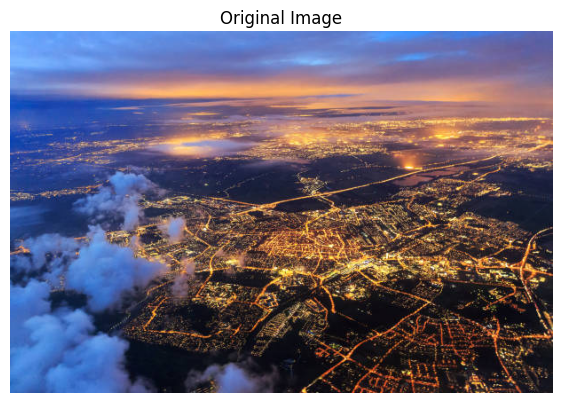

In [4]:
original = read_image(
    IMAGE_PATH
)

print(
    "Image shape:",
    original.shape
)

print(
    "Image dtype:",
    original.dtype
)

show_image(
    original,
    "Original Image"
)

# Kasus 1: Image Blur


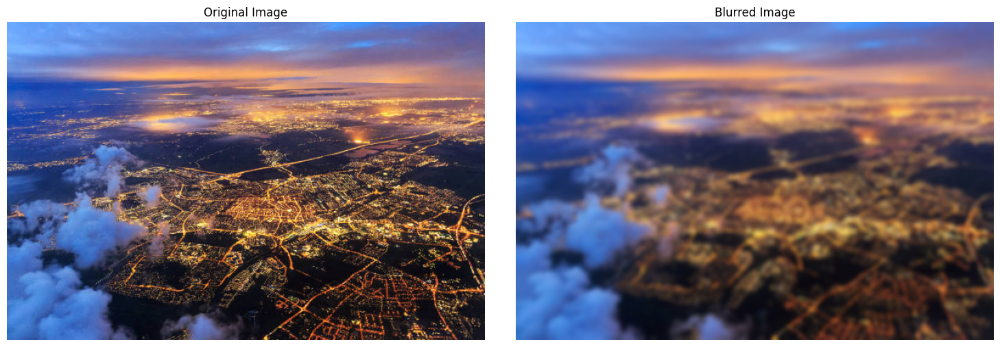

Saved: /content/drive/MyDrive/PCD_Assignment02/outputs/original_blurred_input.jpg


In [5]:
blurred = cv2.GaussianBlur(
    original,
    (11, 11),
    sigmaX=3
)

show_images(
    [
        original,
        blurred
    ],
    [
        "Original Image",
        "Blurred Image"
    ],
    cols=2
)

save_image(
    "original_blurred_input.jpg",
    blurred
)

## Laplacian Sharpening

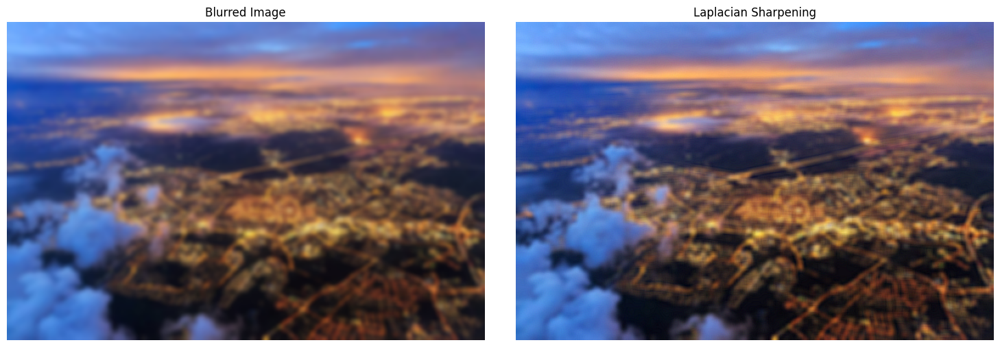

Saved: /content/drive/MyDrive/PCD_Assignment02/outputs/original_blurred_laplacian.jpg


In [6]:
alpha = 0.7

def laplacian_sharpen(
    image,
    alpha=0.7
):

    image_float = image.astype(
        np.float64
    )

    laplacian = cv2.Laplacian(
        image_float,
        cv2.CV_64F,
        ksize=3
    )

    sharpened = (
        image_float
        - alpha * laplacian
    )

    sharpened = np.clip(
        sharpened,
        0,
        255
    )

    return sharpened.astype(
        np.uint8
    )


laplacian_result = laplacian_sharpen(
    blurred,
    alpha
)

show_images(
    [
        blurred,
        laplacian_result
    ],
    [
        "Blurred Image",
        "Laplacian Sharpening"
    ],
    cols=2
)

save_image(
    "original_blurred_laplacian.jpg",
    laplacian_result
)

## Unsharp Masking


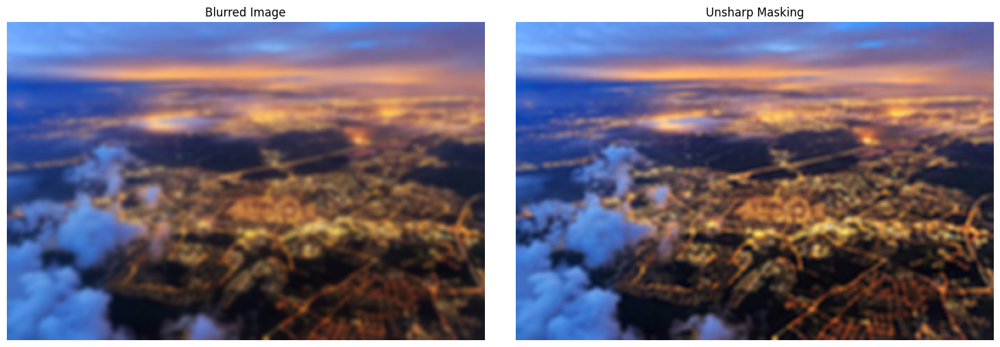

Saved: /content/drive/MyDrive/PCD_Assignment02/outputs/original_blurred_unsharp.jpg


In [7]:
sigma = 2.0
amount = 2.0


def unsharp_mask(
    image,
    sigma=2.0,
    amount=2.0
):

    smoothed = cv2.GaussianBlur(
        image,
        (0, 0),
        sigmaX=sigma
    )

    detail = (
        image.astype(np.float32)
        - smoothed.astype(np.float32)
    )

    enhanced = (
        image.astype(np.float32)
        + amount * detail
    )

    enhanced = np.clip(
        enhanced,
        0,
        255
    )

    return enhanced.astype(
        np.uint8
    )


unsharp_result = unsharp_mask(
    blurred,
    sigma,
    amount
)

show_images(
    [
        blurred,
        unsharp_result
    ],
    [
        "Blurred Image",
        "Unsharp Masking"
    ],
    cols=2
)

save_image(
    "original_blurred_unsharp.jpg",
    unsharp_result
)

## Comparison

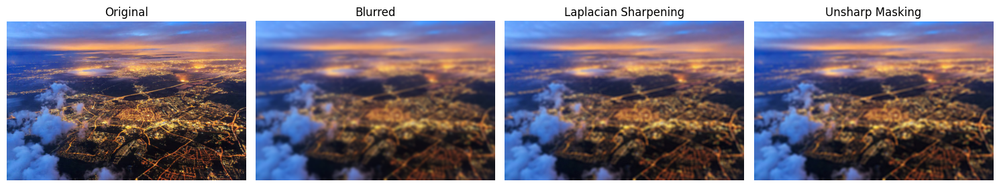

In [8]:
show_images(
    [
        original,
        blurred,
        laplacian_result,
        unsharp_result
    ],
    [
        "Original",
        "Blurred",
        "Laplacian Sharpening",
        "Unsharp Masking"
    ],
    cols=4
)

In [9]:
print("CASE 1 — BLURRED IMAGE")
print("=" * 50)

print(
    f"Blurred          -> "
    f"MSE: {mse(original, blurred):.2f} | "
    f"PSNR: {psnr(original, blurred):.2f} dB"
)

print(
    f"Laplacian        -> "
    f"MSE: {mse(original, laplacian_result):.2f} | "
    f"PSNR: {psnr(original, laplacian_result):.2f} dB"
)

print(
    f"Unsharp Masking  -> "
    f"MSE: {mse(original, unsharp_result):.2f} | "
    f"PSNR: {psnr(original, unsharp_result):.2f} dB"
)

CASE 1 — BLURRED IMAGE
Blurred          -> MSE: 455.03 | PSNR: 21.55 dB
Laplacian        -> MSE: 406.69 | PSNR: 22.04 dB
Unsharp Masking  -> MSE: 397.68 | PSNR: 22.14 dB


## Kasus 2: Image Noise (Salt and Pepper)

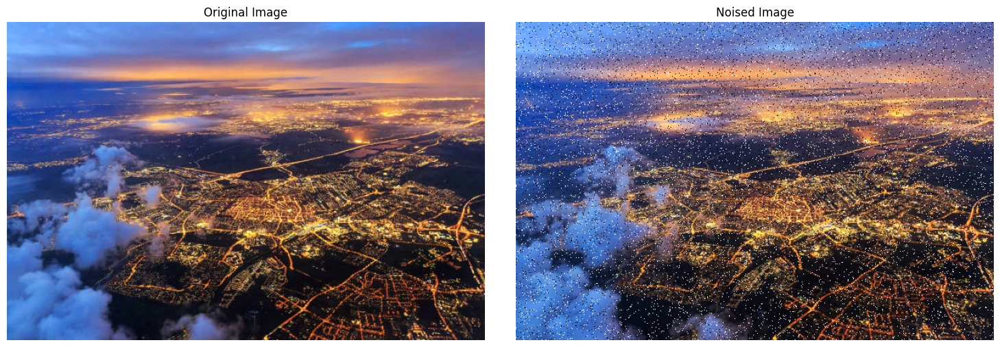

Saved: /content/drive/MyDrive/PCD_Assignment02/outputs/original_noised_input.jpg


In [10]:
def add_salt_pepper_noise(
    image,
    salt_prob=0.03,
    pepper_prob=0.03
):

    noisy = image.copy()

    random = np.random.random(
        image.shape[:2]
    )

    salt = random < salt_prob

    pepper = (
        random >= salt_prob
    ) & (
        random < salt_prob + pepper_prob
    )

    noisy[salt] = 255
    noisy[pepper] = 0

    return noisy


noised = add_salt_pepper_noise(
    original,
    salt_prob=0.03,
    pepper_prob=0.03
)

show_images(
    [
        original,
        noised
    ],
    [
        "Original Image",
        "Noised Image"
    ],
    cols=2
)

save_image(
    "original_noised_input.jpg",
    noised
)

## Average/Mean Filter

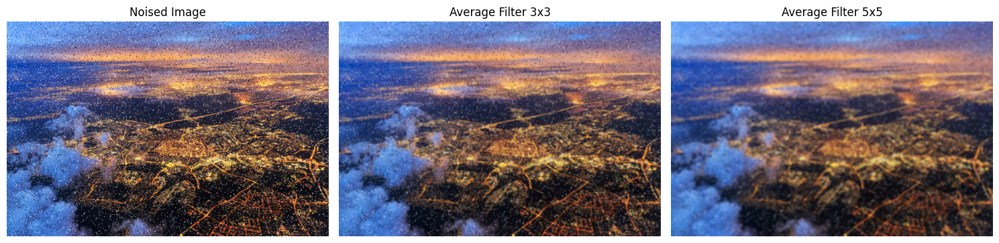

Saved: /content/drive/MyDrive/PCD_Assignment02/outputs/original_noised_average_3x3.jpg
Saved: /content/drive/MyDrive/PCD_Assignment02/outputs/original_noised_average_5x5.jpg


In [11]:
average_3x3 = cv2.blur(
    noised,
    (3, 3)
)

average_5x5 = cv2.blur(
    noised,
    (5, 5)
)

show_images(
    [
        noised,
        average_3x3,
        average_5x5
    ],
    [
        "Noised Image",
        "Average Filter 3x3",
        "Average Filter 5x5"
    ],
    cols=3
)

save_image(
    "original_noised_average_3x3.jpg",
    average_3x3
)

save_image(
    "original_noised_average_5x5.jpg",
    average_5x5
)

## Median Filter

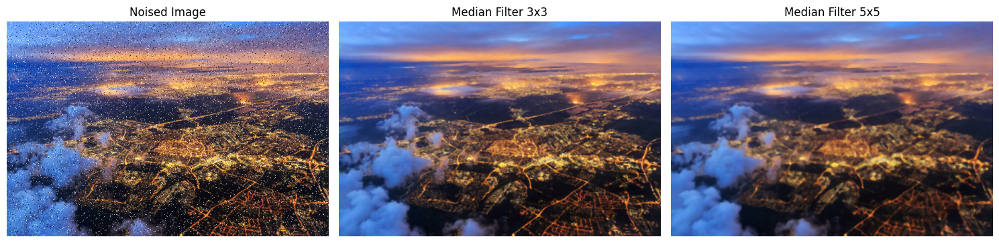

Saved: /content/drive/MyDrive/PCD_Assignment02/outputs/original_noised_median_3x3.jpg
Saved: /content/drive/MyDrive/PCD_Assignment02/outputs/original_noised_median_5x5.jpg


In [12]:
median_3x3 = cv2.medianBlur(
    noised,
    3
)

median_5x5 = cv2.medianBlur(
    noised,
    5
)

show_images(
    [
        noised,
        median_3x3,
        median_5x5
    ],
    [
        "Noised Image",
        "Median Filter 3x3",
        "Median Filter 5x5"
    ],
    cols=3
)

save_image(
    "original_noised_median_3x3.jpg",
    median_3x3
)

save_image(
    "original_noised_median_5x5.jpg",
    median_5x5
)

## Adaptive Median

In [13]:
def adaptive_median_filter_gray(
    image,
    max_window_size=7
):

    if max_window_size % 2 == 0 or max_window_size < 3:
        raise ValueError(
            "max_window_size harus bilangan ganjil dan >= 3."
        )

    image = image.astype(np.uint8)

    pad = max_window_size // 2

    padded = cv2.copyMakeBorder(
        image,
        pad,
        pad,
        pad,
        pad,
        borderType=cv2.BORDER_REFLECT
    )

    output = np.zeros_like(image)

    height, width = image.shape

    for i in range(height):

        for j in range(width):

            z_xy = int(image[i, j])

            result = z_xy

            # Stage A
            for window_size in range(
                3,
                max_window_size + 1,
                2
            ):

                r = window_size // 2

                window = padded[
                    i + pad - r:
                    i + pad + r + 1,

                    j + pad - r:
                    j + pad + r + 1
                ]

                z_min = np.min(window)
                z_max = np.max(window)
                z_med = np.median(window)

                A1 = z_med - z_min
                A2 = z_med - z_max

                if A1 > 0 and A2 < 0:

                    B1 = z_xy - z_min
                    B2 = z_xy - z_max

                    if B1 > 0 and B2 < 0:
                        result = z_xy
                    else:
                        result = z_med

                    break

                if window_size == max_window_size:
                    result = z_med

            output[i, j] = np.clip(
                result,
                0,
                255
            )

    return output


def adaptive_median_filter(
    image,
    max_window_size=7
):

    if len(image.shape) == 2:

        return adaptive_median_filter_gray(
            image,
            max_window_size
        )

    channels = cv2.split(image)

    filtered_channels = []

    for channel in channels:

        filtered_channel = adaptive_median_filter_gray(
            channel,
            max_window_size
        )

        filtered_channels.append(
            filtered_channel
        )

    return cv2.merge(
        filtered_channels
    )

/tmp/ipykernel_20052/755963228.py:63: RuntimeWarning: overflow encountered in scalar subtract
  B2 = z_xy - z_max


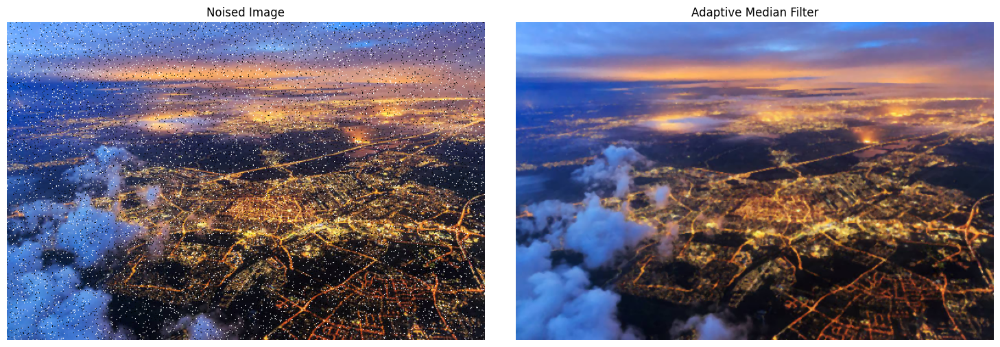

Saved: /content/drive/MyDrive/PCD_Assignment02/outputs/original_noised_adaptive_median.jpg


In [14]:
adaptive_median = adaptive_median_filter(
    noised,
    max_window_size=7
)

show_images(
    [
        noised,
        adaptive_median
    ],
    [
        "Noised Image",
        "Adaptive Median Filter"
    ],
    cols=2
)

save_image(
    "original_noised_adaptive_median.jpg",
    adaptive_median
)

## Comparison

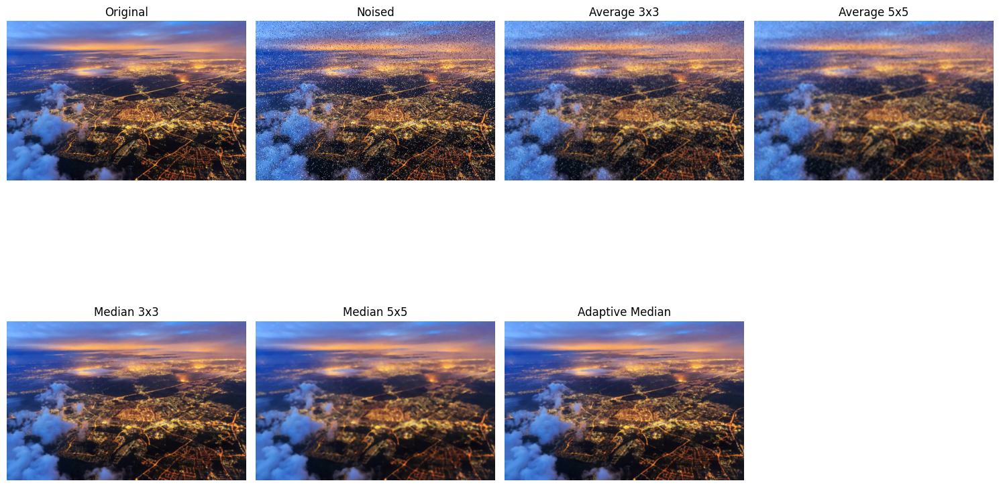

In [15]:
show_images(
    [
        original,
        noised,
        average_3x3,
        average_5x5,
        median_3x3,
        median_5x5,
        adaptive_median
    ],
    [
        "Original",
        "Noised",
        "Average 3x3",
        "Average 5x5",
        "Median 3x3",
        "Median 5x5",
        "Adaptive Median"
    ],
    cols=4
)

In [16]:
results = {
    "Noised": noised,
    "Average 3x3": average_3x3,
    "Average 5x5": average_5x5,
    "Median 3x3": median_3x3,
    "Median 5x5": median_5x5,
    "Adaptive Median": adaptive_median
}

print("CASE 2 — NOISED IMAGE")
print("=" * 60)

for name, result in results.items():

    print(
        f"{name:<18} -> "
        f"MSE: {mse(original, result):8.2f} | "
        f"PSNR: {psnr(original, result):6.2f} dB"
    )

CASE 2 — NOISED IMAGE
Noised             -> MSE:  1236.91 | PSNR:  17.21 dB
Average 3x3        -> MSE:   366.56 | PSNR:  22.49 dB
Average 5x5        -> MSE:   419.04 | PSNR:  21.91 dB
Median 3x3         -> MSE:   213.78 | PSNR:  24.83 dB
Median 5x5         -> MSE:   351.93 | PSNR:  22.67 dB
Adaptive Median    -> MSE:   213.74 | PSNR:  24.83 dB


# Final Comparison

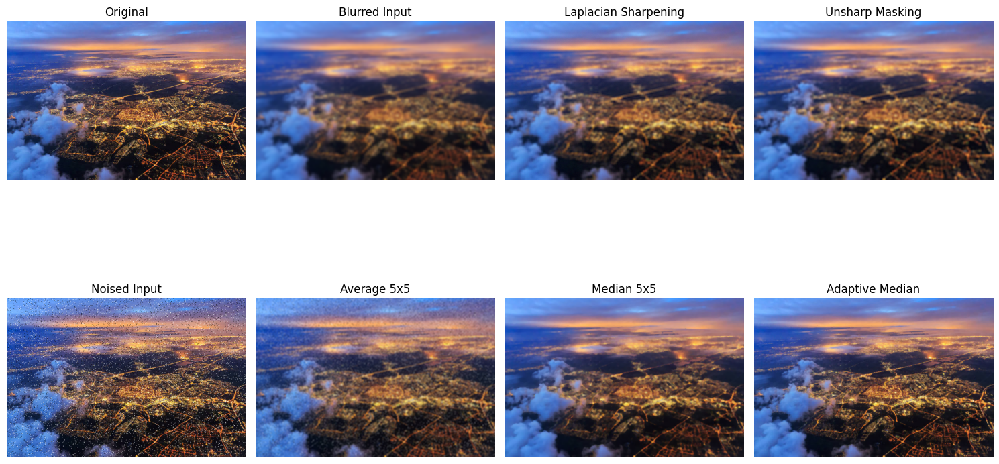

In [17]:
show_images(
    [
        original,
        blurred,
        laplacian_result,
        unsharp_result,
        noised,
        average_5x5,
        median_5x5,
        adaptive_median
    ],
    [
        "Original",
        "Blurred Input",
        "Laplacian Sharpening",
        "Unsharp Masking",
        "Noised Input",
        "Average 5x5",
        "Median 5x5",
        "Adaptive Median"
    ],
    cols=4
)